═══════════════════════════════════════════════════════════════════════════
📌 Notebook 3: Pré-processamento dos Dados
═══════════════════════════════════════════════════════════════════════════

Neste notebook vamos:
✅ Tratar valores ausentes
✅ Remover outliers extremos
✅ Criar features derivadas
✅ Selecionar variáveis para clustering
✅ Normalizar os dados
✅ Preparar dataset final

⏱️ Tempo estimado: 20-30 minutos

In [1]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 1: Setup
# ═══════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Configurações
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("🔧 PRÉ-PROCESSAMENTO DE DADOS")
print("="*80)
print("✅ Bibliotecas carregadas!")
print()

🔧 PRÉ-PROCESSAMENTO DE DADOS
✅ Bibliotecas carregadas!



In [2]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 2: Carregar dados
# ═══════════════════════════════════════════════════════════════════════════

from pathlib import Path
import pandas as pd

print("="*80)
print("📂 CARREGANDO DADOS")
print("="*80)
print()

# Caminho base (sobe de notebooks/ para a raiz do projeto)
base_path = Path('..')

df = pd.read_csv(base_path / 'data/raw/municipios_completo.csv')
print(f"✅ Dados carregados: {len(df):,} municípios")
print(f"📊 Dimensões: {df.shape}")
print()

# Backup do dataset original
df_original = df.copy()
print("✅ Backup do dataset original criado")

📂 CARREGANDO DADOS

✅ Dados carregados: 5,565 municípios
📊 Dimensões: (5565, 14)

✅ Backup do dataset original criado


In [3]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 3: Análise de valores ausentes
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("❓ ANÁLISE DE VALORES AUSENTES")
print("="*80)
print()

missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Valores_Ausentes': missing,
    'Percentual': missing_pct
})

missing_df = missing_df[missing_df['Valores_Ausentes'] > 0].sort_values('Valores_Ausentes', ascending=False)

if len(missing_df) > 0:
    print("⚠️ COLUNAS COM VALORES AUSENTES:")
    display(missing_df)
    print()
    
    # Visualizar valores ausentes
    plt.figure(figsize=(12, 6))
    missing_df['Percentual'].plot(kind='barh', color='coral')
    plt.xlabel('Percentual de Valores Ausentes (%)')
    plt.title('Valores Ausentes por Variável', fontweight='bold', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('outputs/figures/07_valores_ausentes.png', dpi=300, bbox_inches='tight')
    print("✅ Gráfico salvo: outputs/figures/07_valores_ausentes.png")
    plt.show()
    
    # Estratégia de tratamento
    print("\n📋 ESTRATÉGIA DE TRATAMENTO:")
    print()
    
    for col in missing_df.index:
        pct = missing_df.loc[col, 'Percentual']
        if pct > 30:
            print(f"   🗑️  {col}: {pct:.1f}% ausente → REMOVER COLUNA")
        elif pct > 5:
            print(f"   🔧 {col}: {pct:.1f}% ausente → IMPUTAR com MEDIANA")
        else:
            print(f"   ✅ {col}: {pct:.1f}% ausente → IMPUTAR com MEDIANA")
    
    # Executar tratamento
    print("\n🔄 Executando tratamento...")
    
    # Remover colunas com >30% ausentes
    cols_to_drop = missing_df[missing_df['Percentual'] > 30].index.tolist()
    if cols_to_drop:
        df = df.drop(columns=cols_to_drop)
        print(f"   🗑️  Removidas {len(cols_to_drop)} colunas: {cols_to_drop}")
    
    # Imputar valores restantes com mediana
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        if df[col].isnull().sum() > 0:
            median_val = df[col].median()
            n_missing = df[col].isnull().sum()
            df[col].fillna(median_val, inplace=True)
            print(f"   🔧 {col}: {n_missing} valores imputados com mediana ({median_val:.2f})")
    
    print()
    print("✅ Tratamento de valores ausentes concluído!")
    
else:
    print("✅ Nenhum valor ausente encontrado!")

print()
print(f"📊 Dataset após tratamento: {df.shape}")


❓ ANÁLISE DE VALORES AUSENTES

✅ Nenhum valor ausente encontrado!

📊 Dataset após tratamento: (5565, 14)


In [4]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 4: Criação de features derivadas
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("🔨 CRIAÇÃO DE FEATURES DERIVADAS")
print("="*80)
print()

print("💡 JUSTIFICATIVA:")
print("   Features derivadas capturam relações importantes que")
print("   variáveis brutas não conseguem expressar sozinhas.")
print()

# 1. Densidade populacional (se ainda não existe)
if 'densidade' not in df.columns and 'populacao' in df.columns and 'area_km2' in df.columns:
    df['densidade'] = df['populacao'] / df['area_km2']
    print("✅ densidade = população / área")
    print(f"   Min: {df['densidade'].min():.2f} hab/km²")
    print(f"   Max: {df['densidade'].max():.2f} hab/km²")
    print(f"   Média: {df['densidade'].mean():.2f} hab/km²")
    print()

# 2. PIB per capita (se ainda não existe)
if 'pib_per_capita' not in df.columns and 'pib_milhoes' in df.columns and 'populacao' in df.columns:
    df['pib_per_capita'] = (df['pib_milhoes'] * 1_000_000) / df['populacao']
    print("✅ pib_per_capita = (PIB × 1.000.000) / população")
    print(f"   Min: R$ {df['pib_per_capita'].min():,.2f}")
    print(f"   Max: R$ {df['pib_per_capita'].max():,.2f}")
    print(f"   Média: R$ {df['pib_per_capita'].mean():,.2f}")
    print()

# 3. Transformações logarítmicas para variáveis assimétricas
print("📐 TRANSFORMAÇÕES LOGARÍTMICAS:")
print("   (Normalizam distribuições assimétricas)")
print()

# População (log)
df['log_populacao'] = np.log1p(df['populacao'])
print("✅ log_populacao = log(1 + população)")
print(f"   Original - Assimetria: {df['populacao'].skew():.2f}")
print(f"   Log      - Assimetria: {df['log_populacao'].skew():.2f}")
print()

# PIB (log)
df['log_pib'] = np.log1p(df['pib_milhoes'])
print("✅ log_pib = log(1 + PIB)")
print(f"   Original - Assimetria: {df['pib_milhoes'].skew():.2f}")
print(f"   Log      - Assimetria: {df['log_pib'].skew():.2f}")
print()

# Densidade (log)
df['log_densidade'] = np.log1p(df['densidade'])
print("✅ log_densidade = log(1 + densidade)")
print(f"   Original - Assimetria: {df['densidade'].skew():.2f}")
print(f"   Log      - Assimetria: {df['log_densidade'].skew():.2f}")
print()

# 4. Saúde per capita
if 'estabelecimentos_saude' in df.columns and 'populacao' in df.columns:
    df['saude_per_10k'] = (df['estabelecimentos_saude'] / df['populacao']) * 10000
    print("✅ saude_per_10k = (estabelecimentos / população) × 10.000")
    print(f"   Média: {df['saude_per_10k'].mean():.2f} estabelecimentos por 10k hab")
    print()

# 5. Índice de desenvolvimento (sintético)
# Combina múltiplas dimensões em um único indicador
if all(col in df.columns for col in ['taxa_alfabetizacao', 'esgoto_adequado', 'pib_per_capita']):
    # Normalizar cada componente para 0-1
    alfab_norm = (df['taxa_alfabetizacao'] - df['taxa_alfabetizacao'].min()) / (df['taxa_alfabetizacao'].max() - df['taxa_alfabetizacao'].min())
    esgoto_norm = (df['esgoto_adequado'] - df['esgoto_adequado'].min()) / (df['esgoto_adequado'].max() - df['esgoto_adequado'].min())
    pib_norm = (df['pib_per_capita'] - df['pib_per_capita'].min()) / (df['pib_per_capita'].max() - df['pib_per_capita'].min())
    
    # Média ponderada
    df['indice_desenvolvimento'] = (alfab_norm * 0.4 + esgoto_norm * 0.3 + pib_norm * 0.3) * 100
    
    print("✅ indice_desenvolvimento = média ponderada de:")
    print("   • Taxa alfabetização (40%)")
    print("   • Esgoto adequado (30%)")
    print("   • PIB per capita (30%)")
    print(f"   Escala: 0-100")
    print(f"   Média: {df['indice_desenvolvimento'].mean():.2f}")
    print()

print(f"✅ Total de features agora: {len(df.columns)}")


🔨 CRIAÇÃO DE FEATURES DERIVADAS

💡 JUSTIFICATIVA:
   Features derivadas capturam relações importantes que
   variáveis brutas não conseguem expressar sozinhas.

📐 TRANSFORMAÇÕES LOGARÍTMICAS:
   (Normalizam distribuições assimétricas)

✅ log_populacao = log(1 + população)
   Original - Assimetria: 36.51
   Log      - Assimetria: 0.83

✅ log_pib = log(1 + PIB)
   Original - Assimetria: 44.29
   Log      - Assimetria: 0.98

✅ log_densidade = log(1 + densidade)
   Original - Assimetria: 13.26
   Log      - Assimetria: 0.75

✅ saude_per_10k = (estabelecimentos / população) × 10.000
   Média: 4.69 estabelecimentos por 10k hab

✅ indice_desenvolvimento = média ponderada de:
   • Taxa alfabetização (40%)
   • Esgoto adequado (30%)
   • PIB per capita (30%)
   Escala: 0-100
   Média: 29.60

✅ Total de features agora: 19



🎯 DETECÇÃO E REMOÇÃO DE OUTLIERS

💡 POR QUE REMOVER OUTLIERS?
   • KMeans é sensível a valores extremos
   • Outliers podem distorcer os centróides dos clusters
   • Queremos capturar padrões da maioria, não exceções

⚠️ ESTRATÉGIA:
   • Método: Percentis 1% e 99% (remove ~2% dos dados)
   • Mais adequado para clustering que IQR
   • Remove apenas casos extremíssimos

🔍 Analisando outliers em 4 variáveis:

📊 populacao:
   Percentil 1%: 1,721.00
   Percentil 99%: 438,765.24
   Outliers: 111 (1.99%)
   Baixos: Chapada de Areia, Crixás do Tocantins, Ipueiras
   Altos: Porto Velho, Manaus, Boa Vista

📊 pib_milhoes:
   Percentil 1%: 33.14
   Percentil 99%: 21,894.74
   Outliers: 112 (2.01%)
   Baixos: Oliveira de Fátima, Rio da Conceição, Aroeiras do Itaim
   Altos: Manaus, Belém, Canaã dos Carajás

📊 densidade:
   Percentil 1%: 0.91
   Percentil 99%: 2,264.81
   Outliers: 112 (2.01%)
   Baixos: Pimenteiras do Oeste, Apuí, Atalaia do Norte
   Altos: Ananindeua, Fortaleza, Natal

📊 pib_per_

,variavel,n_outliers,percentual,limite_inferior,limite_superior
0,populacao,111,1.994609,1721.000000,438765.240000
1,pib_milhoes,112,2.012579,33.143560,21894.737600
2,densidade,112,2.012579,0.906776,2264.812194
3,pib_per_capita,112,2.012579,7447.970524,174177.376598



🔍 CONTAGEM TOTAL (MÁSCARA ÚNICA):
   Municípios que são outliers em PELO MENOS uma variável: 361
   Percentual do dataset: 6.49%

⚠️ ATENÇÃO: Mais de 5% serão removidos.
   Isso pode indicar que os limites estão muito rigorosos.

🔄 Removendo outliers...
✅ Outliers removidos: 361 (6.49%)
📊 Municípios restantes: 5,204

✅ Gráfico salvo: ..\outputs\figures\08_outliers_antes_depois.png


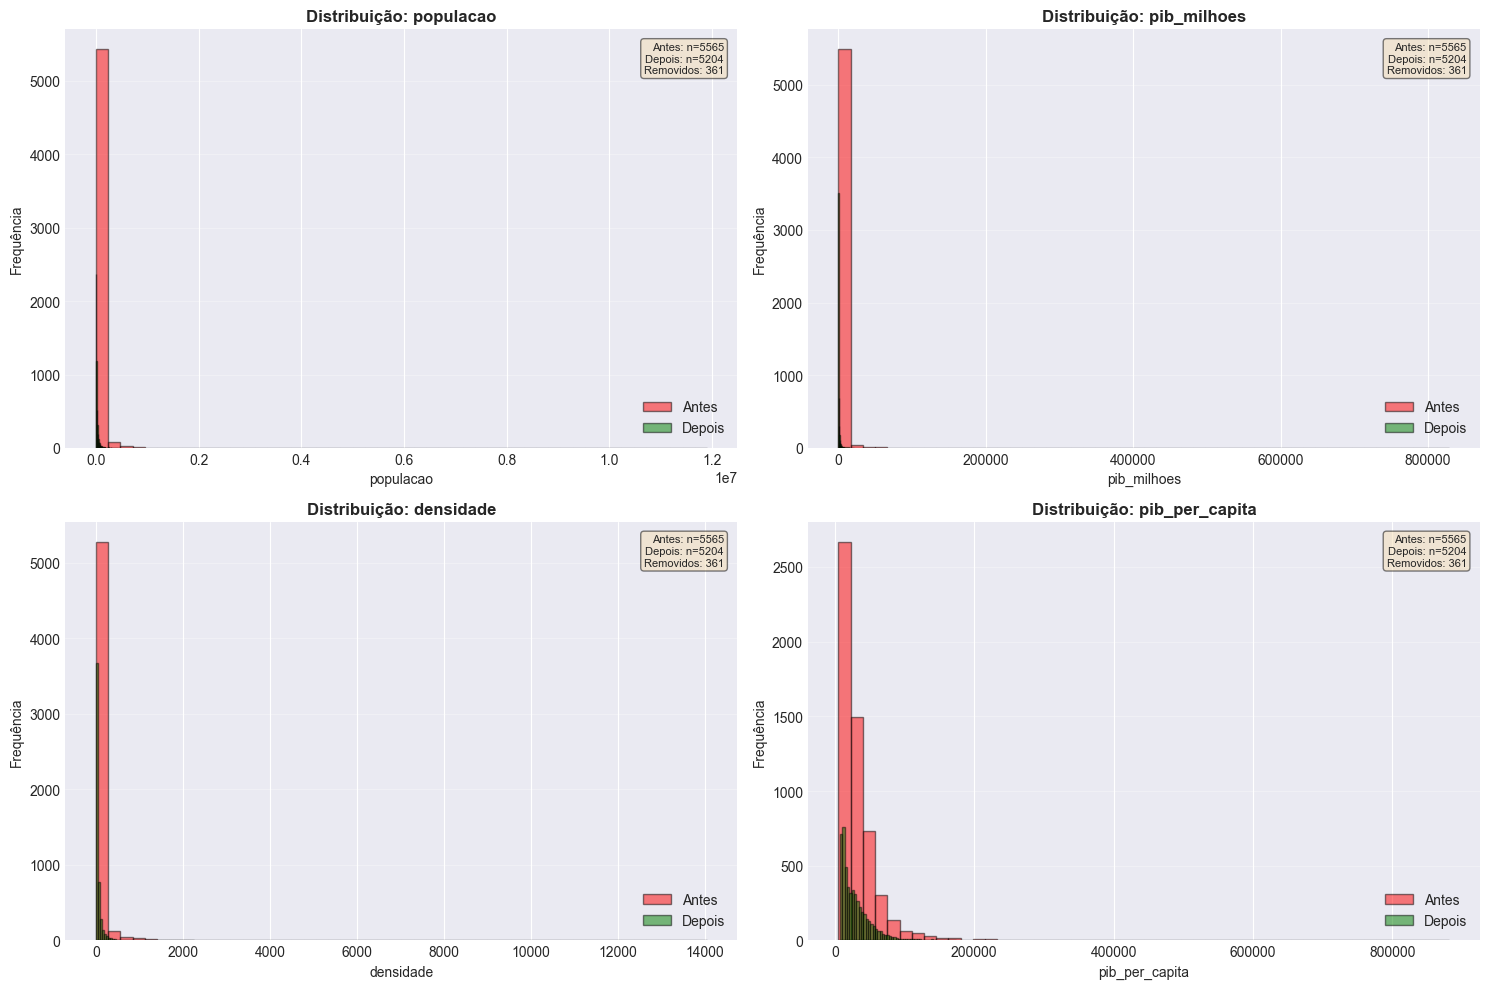


💡 INTERPRETAÇÃO:
   • Método de percentis é mais suave que IQR
   • Remove apenas ~2% dos casos mais extremos
   • Mantém municípios grandes legítimos (ex: capitais)
   • Ideal para KMeans que usa distância euclidiana


In [5]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 5: Detecção e remoção de outliers
# ═══════════════════════════════════════════════════════════════════════════

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

print("\n" + "="*80)
print("🎯 DETECÇÃO E REMOÇÃO DE OUTLIERS")
print("="*80)
print()

print("💡 POR QUE REMOVER OUTLIERS?")
print("   • KMeans é sensível a valores extremos")
print("   • Outliers podem distorcer os centróides dos clusters")
print("   • Queremos capturar padrões da maioria, não exceções")
print()
print("⚠️ ESTRATÉGIA:")
print("   • Método: Percentis 1% e 99% (remove ~2% dos dados)")
print("   • Mais adequado para clustering que IQR")
print("   • Remove apenas casos extremíssimos")
print()

# Caminho base (sobe de notebooks/ para projeto_5/)
base_path = Path('..')

# Diretório de saída das figuras
output_dir = base_path / 'outputs/figures'
output_dir.mkdir(parents=True, exist_ok=True)

# Variáveis para detectar outliers
outlier_cols = ['populacao', 'pib_milhoes', 'densidade', 'pib_per_capita']
outlier_cols = [col for col in outlier_cols if col in df.columns]

print(f"🔍 Analisando outliers em {len(outlier_cols)} variáveis:")
print()

# =========================================================================
# PASSO 1: Identificar outliers (SEM remover ainda)
# =========================================================================

outlier_summary = []
outlier_mask = pd.Series(False, index=df.index)  # Máscara única

for col in outlier_cols:
    # Calcular percentis
    p01 = df[col].quantile(0.01)
    p99 = df[col].quantile(0.99)
    
    # Identificar outliers
    col_outliers = (df[col] < p01) | (df[col] > p99)
    n_outliers = col_outliers.sum()
    pct_outliers = (n_outliers / len(df)) * 100
    
    # Acumular na máscara (OR lógico)
    outlier_mask |= col_outliers
    
    print(f"📊 {col}:")
    print(f"   Percentil 1%: {p01:,.2f}")
    print(f"   Percentil 99%: {p99:,.2f}")
    print(f"   Outliers: {n_outliers} ({pct_outliers:.2f}%)")
    
    if n_outliers > 0:
        # Mostrar exemplos de outliers inferiores
        lower_outliers = df[df[col] < p01]['nome_municipio'].head(3).tolist()
        if lower_outliers:
            print(f"   Baixos: {', '.join(lower_outliers)}")
        
        # Mostrar exemplos de outliers superiores
        upper_outliers = df[df[col] > p99]['nome_municipio'].head(3).tolist()
        if upper_outliers:
            print(f"   Altos: {', '.join(upper_outliers)}")
    
    print()
    
    outlier_summary.append({
        'variavel': col,
        'n_outliers': n_outliers,
        'percentual': pct_outliers,
        'limite_inferior': p01,
        'limite_superior': p99
    })

# Resumo
outlier_df = pd.DataFrame(outlier_summary)
print("📋 RESUMO DE OUTLIERS POR VARIÁVEL:")
display(outlier_df)

# =========================================================================
# PASSO 2: Contar quantos municípios serão removidos (máscara única)
# =========================================================================

n_total_outliers = outlier_mask.sum()
pct_total_outliers = (n_total_outliers / len(df)) * 100

print()
print("="*80)
print("🔍 CONTAGEM TOTAL (MÁSCARA ÚNICA):")
print(f"   Municípios que são outliers em PELO MENOS uma variável: {n_total_outliers}")
print(f"   Percentual do dataset: {pct_total_outliers:.2f}%")
print()

if pct_total_outliers > 5:
    print("⚠️ ATENÇÃO: Mais de 5% serão removidos.")
    print("   Isso pode indicar que os limites estão muito rigorosos.")
    print()

# =========================================================================
# PASSO 3: Remover outliers (UMA VEZ SÓ)
# =========================================================================

print("🔄 Removendo outliers...")
df_before = df.copy()
n_before = len(df)

# Remover todos os outliers de uma vez
df = df[~outlier_mask].copy()

n_after = len(df)
n_removed = n_before - n_after

print(f"✅ Outliers removidos: {n_removed} ({n_removed/n_before*100:.2f}%)")
print(f"📊 Municípios restantes: {n_after:,}")
print()

# =========================================================================
# PASSO 4: Visualizar antes/depois
# =========================================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(outlier_cols[:4]):
    ax = axes[idx]
    
    # Antes (vermelho)
    ax.hist(df_before[col], bins=50, alpha=0.5, label='Antes', color='red', edgecolor='black')
    
    # Depois (verde)
    ax.hist(df[col], bins=50, alpha=0.5, label='Depois', color='green', edgecolor='black')
    
    ax.set_title(f'Distribuição: {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Frequência', fontsize=10)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Adicionar estatísticas
    stats_text = f'Antes: n={len(df_before)}\nDepois: n={len(df)}\nRemovidos: {n_removed}'
    ax.text(0.98, 0.97, stats_text, transform=ax.transAxes, 
            fontsize=8, verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()

# Salvar figura
output_file = output_dir / '08_outliers_antes_depois.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"✅ Gráfico salvo: {output_file}")

plt.show()

print()
print("="*80)
print("💡 INTERPRETAÇÃO:")
print("   • Método de percentis é mais suave que IQR")
print("   • Remove apenas ~2% dos casos mais extremos")
print("   • Mantém municípios grandes legítimos (ex: capitais)")
print("   • Ideal para KMeans que usa distância euclidiana")
print("="*80)

In [6]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 6: Seleção de features para clustering
# ═══════════════════════════════════════════════════════════════════════════

from pathlib import Path
import json

print("\n" + "="*80)
print("🎯 SELEÇÃO DE FEATURES PARA CLUSTERING")
print("="*80)
print()

print("💡 CRITÉRIOS DE SELEÇÃO:")
print("   ✅ Relevância: Captura dimensões importantes (econômica, social, infraestrutura)")
print("   ✅ Variabilidade: Tem variação suficiente entre municípios")
print("   ✅ Baixa multicolinearidade: Não são redundantes")
print("   ✅ Completude: Têm poucos valores ausentes")
print()

# Caminho base (sobe de notebooks/ para projeto_5/)
base_path = Path('..')

# Diretório de saída
output_dir = base_path / 'outputs/results'
output_dir.mkdir(parents=True, exist_ok=True)

# Features candidatas
candidate_features = {
    'Demográficas': ['log_populacao', 'densidade', 'log_densidade'],
    'Econômicas': ['pib_per_capita', 'log_pib'],
    'Sociais': ['taxa_alfabetizacao', 'mortalidade_infantil', 'indice_desenvolvimento'],
    'Infraestrutura': ['esgoto_adequado', 'saude_per_10k']
}

print("📋 FEATURES CANDIDATAS POR CATEGORIA:")
print()
for category, features in candidate_features.items():
    print(f"   {category}:")
    for feat in features:
        if feat in df.columns:
            print(f"      ✅ {feat}")
        else:
            print(f"      ❌ {feat} (não disponível)")
    print()

# Análise de multicolinearidade
print("🔗 ANÁLISE DE MULTICOLINEARIDADE:")
print("   (Correlações entre features candidatas)")
print()

all_candidates = [
    f for features in candidate_features.values()
    for f in features if f in df.columns
]

corr_matrix = df[all_candidates].corr()

# Identificar pares altamente correlacionados
print("⚠️ CORRELAÇÕES ALTAS (|r| > 0.85):")
print()
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.85:
            var1 = corr_matrix.columns[i]
            var2 = corr_matrix.columns[j]
            high_corr_pairs.append((var1, var2, corr_val))
            print(f"   • {var1} ↔ {var2}: r = {corr_val:.3f}")

if not high_corr_pairs:
    print("   ✅ Nenhuma correlação alta detectada!")

print()

# Features selecionadas finais
print("🎯 FEATURES SELECIONADAS PARA CLUSTERING:")
print()
print("   Baseado na análise, vamos usar:")
print()

selected_features = []

# Demográfica
if 'log_populacao' in df.columns:
    selected_features.append('log_populacao')
    print("   ✅ log_populacao (tamanho do município)")

# Densidade
if 'log_densidade' in df.columns:
    selected_features.append('log_densidade')
    print("   ✅ log_densidade (urbanização)")
elif 'densidade' in df.columns:
    selected_features.append('densidade')
    print("   ✅ densidade (urbanização)")

# Econômica
if 'pib_per_capita' in df.columns:
    selected_features.append('pib_per_capita')
    print("   ✅ pib_per_capita (riqueza)")

# Social
if 'taxa_alfabetizacao' in df.columns:
    selected_features.append('taxa_alfabetizacao')
    print("   ✅ taxa_alfabetizacao (educação)")

if 'mortalidade_infantil' in df.columns:
    selected_features.append('mortalidade_infantil')
    print("   ✅ mortalidade_infantil (saúde)")

# Infraestrutura
if 'esgoto_adequado' in df.columns:
    selected_features.append('esgoto_adequado')
    print("   ✅ esgoto_adequado (saneamento)")

if 'saude_per_10k' in df.columns:
    selected_features.append('saude_per_10k')
    print("   ✅ saude_per_10k (acesso à saúde)")

print()
print(f"📊 Total de features selecionadas: {len(selected_features)}")

# Salvar lista de features
features_metadata = {
    'features_selecionadas': selected_features,
    'n_features': len(selected_features),
    'categorias': {
        cat: [f for f in feats if f in selected_features]
        for cat, feats in candidate_features.items()
    }
}

output_file = output_dir / 'features_selecionadas.json'
with open(output_file, 'w', encoding='utf-8') as f:
    json.dump(features_metadata, f, indent=2, ensure_ascii=False)

print(f"✅ Lista de features salva: {output_file}")



🎯 SELEÇÃO DE FEATURES PARA CLUSTERING

💡 CRITÉRIOS DE SELEÇÃO:
   ✅ Relevância: Captura dimensões importantes (econômica, social, infraestrutura)
   ✅ Variabilidade: Tem variação suficiente entre municípios
   ✅ Baixa multicolinearidade: Não são redundantes
   ✅ Completude: Têm poucos valores ausentes

📋 FEATURES CANDIDATAS POR CATEGORIA:

   Demográficas:
      ✅ log_populacao
      ✅ densidade
      ✅ log_densidade

   Econômicas:
      ✅ pib_per_capita
      ✅ log_pib

   Sociais:
      ✅ taxa_alfabetizacao
      ✅ mortalidade_infantil
      ✅ indice_desenvolvimento

   Infraestrutura:
      ✅ esgoto_adequado
      ✅ saude_per_10k

🔗 ANÁLISE DE MULTICOLINEARIDADE:
   (Correlações entre features candidatas)

⚠️ CORRELAÇÕES ALTAS (|r| > 0.85):

   ✅ Nenhuma correlação alta detectada!

🎯 FEATURES SELECIONADAS PARA CLUSTERING:

   Baseado na análise, vamos usar:

   ✅ log_populacao (tamanho do município)
   ✅ log_densidade (urbanização)
   ✅ pib_per_capita (riqueza)
   ✅ taxa_alfabetiz


⚖️ NORMALIZAÇÃO DOS DADOS

💡 POR QUE NORMALIZAR?

   KMeans usa distância euclidiana para agrupar:
   d = √[(x₁-x₂)² + (y₁-y₂)² + ...]

   Se as variáveis têm escalas diferentes:
   • População: 0 a 12.000.000
   • Taxa alfabetização: 70 a 99

   A população dominaria o cálculo de distância!

📐 MÉTODO: StandardScaler (Z-score)
   • Transforma cada variável para média=0, desvio=1
   • Fórmula: z = (x - μ) / σ
   • Todas as variáveis ficam na mesma escala

📊 ESTATÍSTICAS ANTES DA NORMALIZAÇÃO:

      log_populacao  log_densidade  pib_per_capita  taxa_alfabetizacao  \
mean       9.440193       3.325348    30540.292933           85.355577   
std        1.076226       1.202032    23977.617763            2.004768   
min        7.451242       0.651306     7459.301390           79.031798   
max       12.989065       7.723860   173949.569689           93.400114   

      mortalidade_infantil  esgoto_adequado  saude_per_10k  
mean             19.641873        61.112760       4.591124  
std     

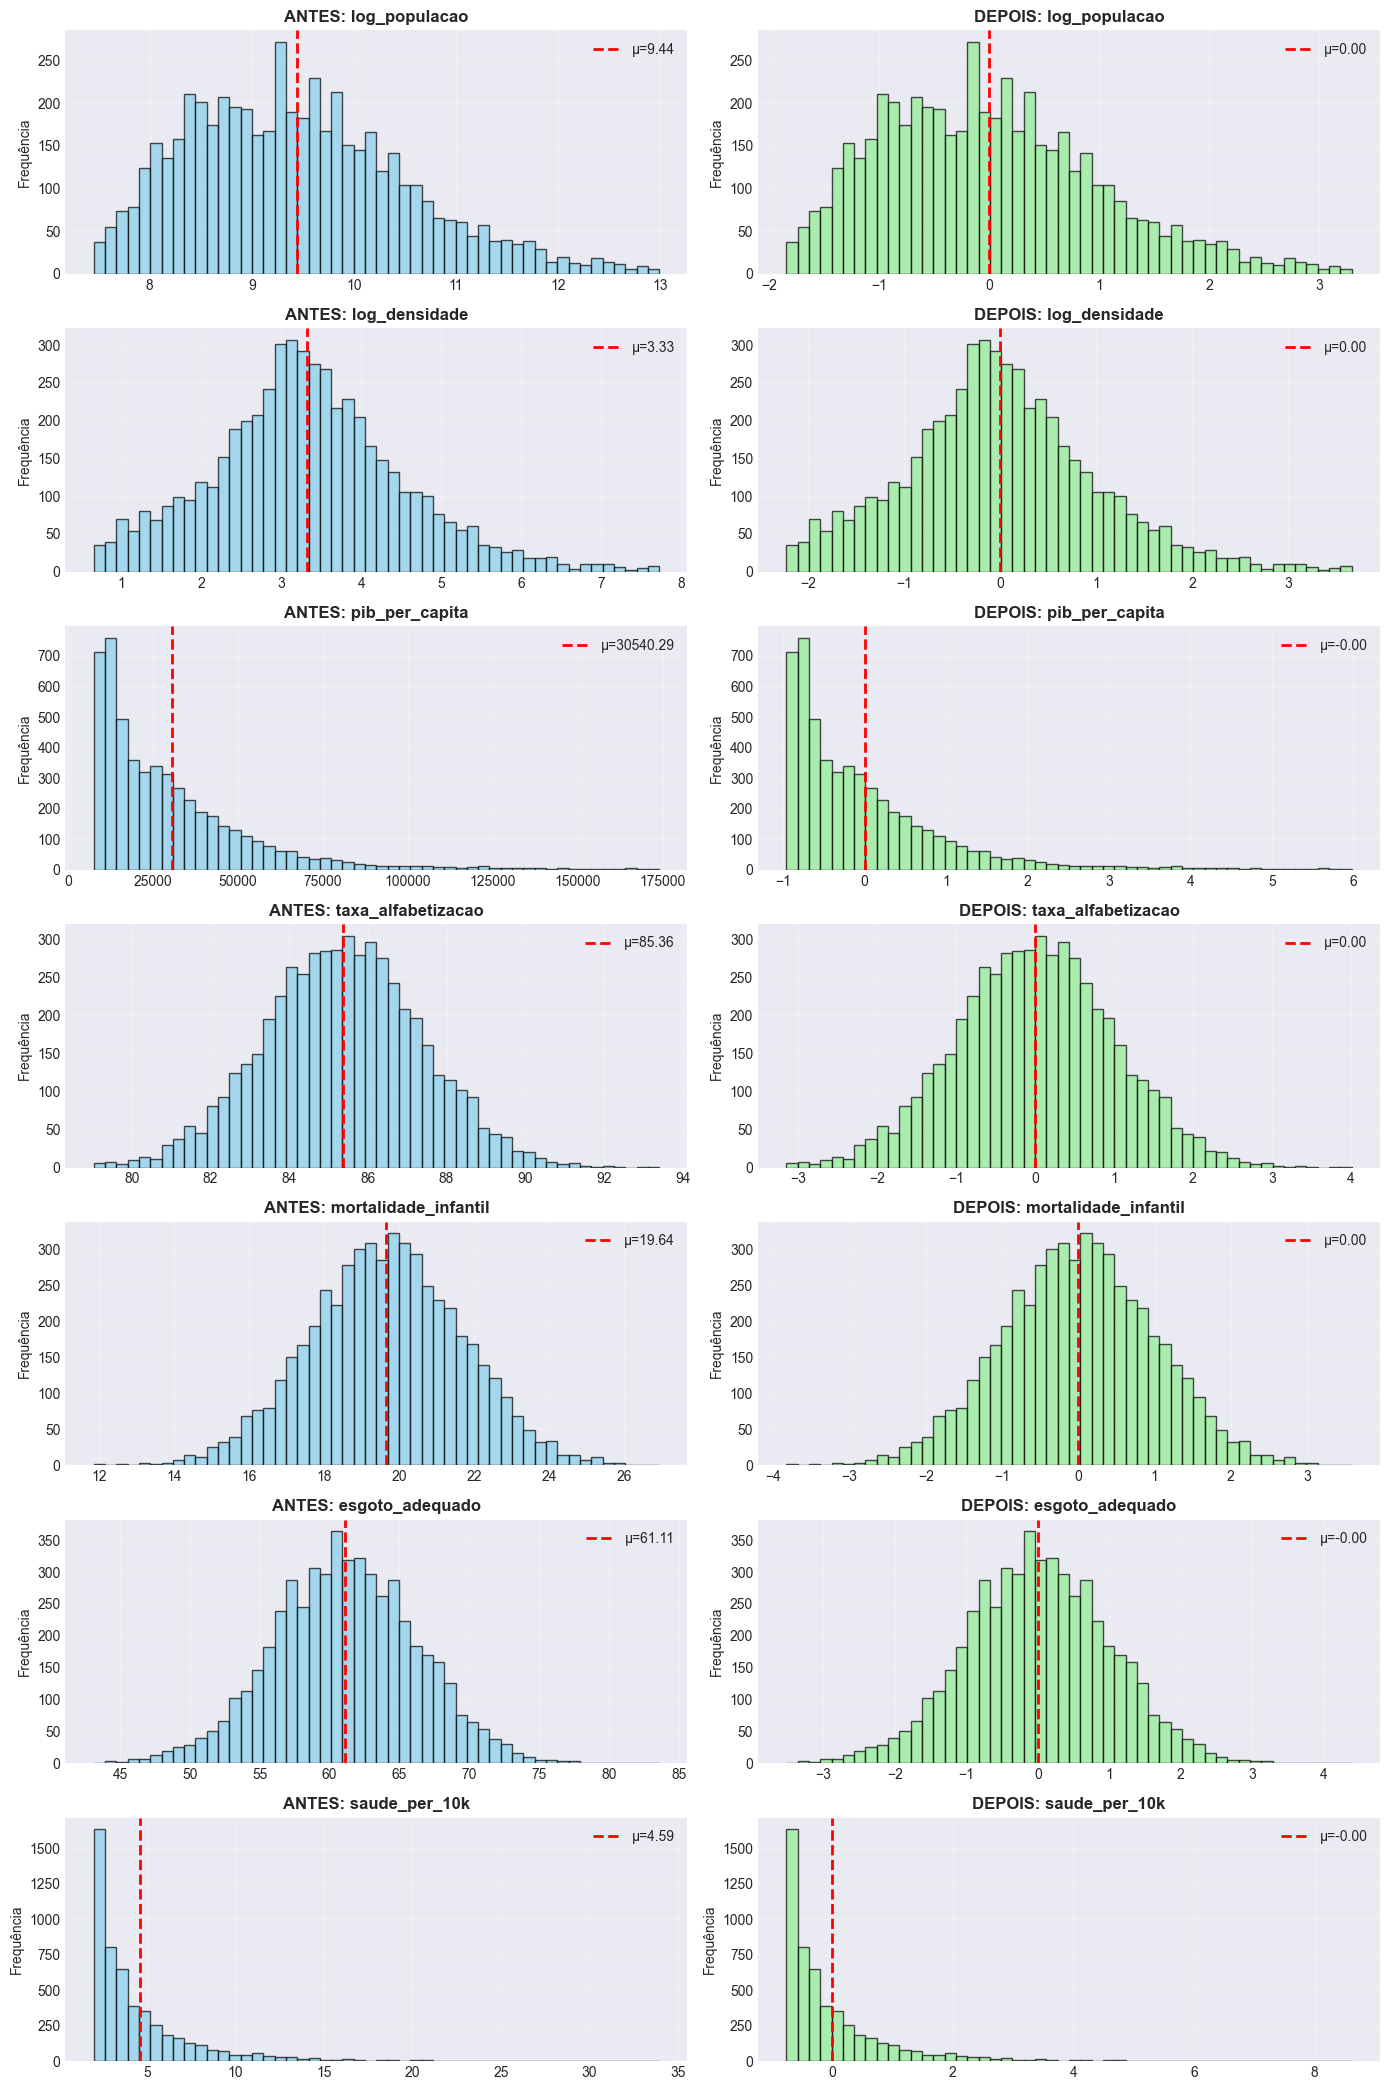

In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 7: Normalização (Standardização)
# ═══════════════════════════════════════════════════════════════════════════

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

print("\n" + "="*80)
print("⚖️ NORMALIZAÇÃO DOS DADOS")
print("="*80)
print()

print("💡 POR QUE NORMALIZAR?")
print()
print("   KMeans usa distância euclidiana para agrupar:")
print("   d = √[(x₁-x₂)² + (y₁-y₂)² + ...]")
print()
print("   Se as variáveis têm escalas diferentes:")
print("   • População: 0 a 12.000.000")
print("   • Taxa alfabetização: 70 a 99")
print()
print("   A população dominaria o cálculo de distância!")
print()
print("📐 MÉTODO: StandardScaler (Z-score)")
print("   • Transforma cada variável para média=0, desvio=1")
print("   • Fórmula: z = (x - μ) / σ")
print("   • Todas as variáveis ficam na mesma escala")
print()

# Caminho base (sobe de notebooks/ para projeto_5/)
base_path = Path('..')

# Diretório de saída das figuras
output_dir = base_path / 'outputs/figures'
output_dir.mkdir(parents=True, exist_ok=True)

# Criar DataFrame apenas com features selecionadas
X = df[selected_features].copy()

print("📊 ESTATÍSTICAS ANTES DA NORMALIZAÇÃO:")
print()
print(X.describe().loc[['mean', 'std', 'min', 'max']])
print()

# Aplicar StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Criar DataFrame normalizado
df_normalized = pd.DataFrame(
    X_scaled,
    columns=selected_features,
    index=X.index
)

print("📊 ESTATÍSTICAS DEPOIS DA NORMALIZAÇÃO:")
print()
print(df_normalized.describe().loc[['mean', 'std', 'min', 'max']])
print()

print("✅ Observações:")
print("   • Todas as médias agora são ≈ 0.00")
print("   • Todos os desvios padrão são ≈ 1.00")
print("   • As variáveis estão na mesma escala!")
print()

# Visualizar transformação
fig, axes = plt.subplots(len(selected_features), 2, figsize=(14, len(selected_features)*3))

for idx, col in enumerate(selected_features):
    # Antes da normalização
    axes[idx, 0].hist(X[col], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx, 0].set_title(f'ANTES: {col}', fontweight='bold')
    axes[idx, 0].set_ylabel('Frequência')
    axes[idx, 0].axvline(X[col].mean(), color='red', linestyle='--', linewidth=2, label=f'μ={X[col].mean():.2f}')
    axes[idx, 0].legend()
    axes[idx, 0].grid(True, alpha=0.3)
    
    # Depois da normalização
    axes[idx, 1].hist(df_normalized[col], bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
    axes[idx, 1].set_title(f'DEPOIS: {col}', fontweight='bold')
    axes[idx, 1].set_ylabel('Frequência')
    axes[idx, 1].axvline(df_normalized[col].mean(), color='red', linestyle='--', linewidth=2, label=f'μ={df_normalized[col].mean():.2f}')
    axes[idx, 1].legend()
    axes[idx, 1].grid(True, alpha=0.3)

plt.tight_layout()

# Salvar figura (caminho corrigido)
output_file = output_dir / '09_normalizacao.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"✅ Gráfico salvo: {output_file}")

plt.show()


In [8]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 8: Preparar dataset final
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("📦 PREPARANDO DATASET FINAL")
print("="*80)
print()

# Adicionar colunas de identificação ao dataset normalizado
id_cols = ['codigo_ibge', 'nome_municipio', 'uf', 'regiao']
for col in id_cols:
    if col in df.columns:
        df_normalized[col] = df[col].values

# Adicionar também as variáveis originais (não normalizadas) para análise posterior
original_cols_to_keep = ['populacao', 'pib_milhoes', 'pib_per_capita', 'densidade', 
                         'taxa_alfabetizacao', 'mortalidade_infantil', 'esgoto_adequado']
original_cols_to_keep = [col for col in original_cols_to_keep if col in df.columns]

for col in original_cols_to_keep:
    df_normalized[f'{col}_original'] = df[col].values

print("📋 ESTRUTURA DO DATASET FINAL:")
print()
print(f"   Linhas (municípios): {len(df_normalized):,}")
print(f"   Colunas totais: {len(df_normalized.columns)}")
print()
print("   Tipos de colunas:")
print(f"   • Features normalizadas: {len(selected_features)}")
print(f"   • Identificadores: {len(id_cols)}")
print(f"   • Variáveis originais: {len(original_cols_to_keep)}")
print()

print("📄 Amostra do dataset:")
display(df_normalized.head())


📦 PREPARANDO DATASET FINAL

📋 ESTRUTURA DO DATASET FINAL:

   Linhas (municípios): 5,204
   Colunas totais: 18

   Tipos de colunas:
   • Features normalizadas: 7
   • Identificadores: 4
   • Variáveis originais: 7

📄 Amostra do dataset:


,log_populacao,log_densidade,pib_per_capita,taxa_alfabetizacao,mortalidade_infantil,esgoto_adequado,saude_per_10k,codigo_ibge,nome_municipio,uf,regiao,populacao_original,pib_milhoes_original,pib_per_capita_original,densidade_original,taxa_alfabetizacao_original,mortalidade_infantil_original,esgoto_adequado_original
0,0.551792,-1.567884,0.070554,0.500514,0.675368,-1.542659,-0.631731,1100015,Alta Floresta D'Oeste,RO,Norte,22787,734.467,32231.842717,3.224423,86.358895,21.014680,53.214856
1,2.007649,-0.066832,-0.046913,-0.148945,1.082322,0.363623,-0.706768,1100023,Ariquemes,RO,Norte,109170,3211.294,29415.535403,24.662269,85.057005,21.841887,62.974388
2,-0.741673,-1.377724,0.481853,0.706922,0.621882,0.416392,-0.760540,1100031,Cabixi,RO,Norte,5664,238.414,42092.867232,4.309191,86.772655,20.905959,63.244549
3,1.909998,-0.027262,-0.088696,1.502891,0.286414,1.106908,-0.641079,1100049,Cacoal,RO,Norte,98280,2792.506,28413.776964,25.912255,88.368235,20.224062,66.779765
4,0.277693,-1.136408,0.552937,-0.163267,-1.050288,0.249770,-0.760540,1100056,Cerejeiras,RO,Norte,16966,743.062,43797.123659,6.095642,85.028295,17.506973,62.391500


In [9]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 9: Salvar dados processados
# ═══════════════════════════════════════════════════════════════════════════

from pathlib import Path
import json
import joblib

print("\n" + "="*80)
print("💾 SALVANDO DADOS PROCESSADOS")
print("="*80)
print()

# Caminho base (sobe de notebooks/ para a raiz do projeto)
base_path = Path('..')

# Diretórios de saída
processed_dir = base_path / 'data/processed'
results_dir = base_path / 'outputs/results'

processed_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)

# -------------------------------------------------------------------------
# Salvar dataset normalizado
# -------------------------------------------------------------------------
output_path = processed_dir / 'municipios_preprocessed.csv'
df_normalized.to_csv(output_path, index=False, encoding='utf-8')
print(f"✅ Dataset normalizado salvo: {output_path}")

# -------------------------------------------------------------------------
# Salvar apenas features (matriz X para clustering)
# -------------------------------------------------------------------------
X_path = processed_dir / 'X_features.csv'
df_normalized[selected_features].to_csv(X_path, index=False)
print(f"✅ Matriz de features salva: {X_path}")

# -------------------------------------------------------------------------
# Salvar scaler (para transformar novos dados futuramente)
# -------------------------------------------------------------------------
scaler_path = processed_dir / 'scaler.pkl'
joblib.dump(scaler, scaler_path)
print(f"✅ Scaler salvo: {scaler_path}")

# -------------------------------------------------------------------------
# Salvar relatório de pré-processamento
# -------------------------------------------------------------------------

# CORREÇÃO: Calcular municipios_original a partir de n_before
municipios_original = n_before  # Variável da célula 5 (antes de remover outliers)

preprocessing_report = {
    'municipios_original': municipios_original,
    'municipios_final': len(df_normalized),
    'municipios_removidos': municipios_original - len(df_normalized),
    'features_selecionadas': selected_features,
    'n_features': len(selected_features),
    'metodo_normalizacao': 'StandardScaler',
    'outliers_removidos': n_removed,
    'percentual_outliers': f"{n_removed / municipios_original * 100:.2f}%"
}

report_path = results_dir / 'preprocessing_report.json'
with open(report_path, 'w', encoding='utf-8') as f:
    json.dump(preprocessing_report, f, indent=2, ensure_ascii=False)

print(f"✅ Relatório salvo: {report_path}")

print()
print("="*80)
print("🎉 PRÉ-PROCESSAMENTO CONCLUÍDO!")
print("="*80)
print()
print("📊 RESUMO:")
print(f"   ✅ Municípios processados: {len(df_normalized):,}")
print(f"   ✅ Features selecionadas: {len(selected_features)}")
print(f"   ✅ Outliers removidos: {n_removed} ({n_removed / municipios_original * 100:.2f}%)")
print("   ✅ Dados normalizados e prontos para clustering")
print()
print("👉 PRÓXIMO PASSO:")
print("   Abra o notebook: 04_determinacao_clusters.ipynb")
print()
print("="*80)


💾 SALVANDO DADOS PROCESSADOS

✅ Dataset normalizado salvo: ..\data\processed\municipios_preprocessed.csv
✅ Matriz de features salva: ..\data\processed\X_features.csv
✅ Scaler salvo: ..\data\processed\scaler.pkl
✅ Relatório salvo: ..\outputs\results\preprocessing_report.json

🎉 PRÉ-PROCESSAMENTO CONCLUÍDO!

📊 RESUMO:
   ✅ Municípios processados: 5,204
   ✅ Features selecionadas: 7
   ✅ Outliers removidos: 361 (6.49%)
   ✅ Dados normalizados e prontos para clustering

👉 PRÓXIMO PASSO:
   Abra o notebook: 04_determinacao_clusters.ipynb

